# IMPORTING LIBRARIES AND LOADING DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split


file_path = 'Churn_Modelling.csv' 
data = pd.read_csv(file_path)

ModuleNotFoundError: No module named 'pandas'

# DATA INSIGHTS / HANDLING MISSING VALUES

In [2]:
print(data.info())
print(data.describe())

print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

# Dropping Unwanted Features

In [3]:
X = data.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname','Geography','Age','Gender'])
X = pd.get_dummies(X, drop_first=True)

print(X.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   CreditScore  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0          619       2       0.00              1          1               1   
1          608       1   83807.86              1          0               1   
2          502       8  159660.80              3          1               0   
3          699       1       0.00              2          0               0   
4          850       2  125510.82              1          1               1   

   EstimatedSalary  
0        101348.88  
1        112542.58  
2        113931.57  
3         93826.63  
4         79084.10  


# Correlation

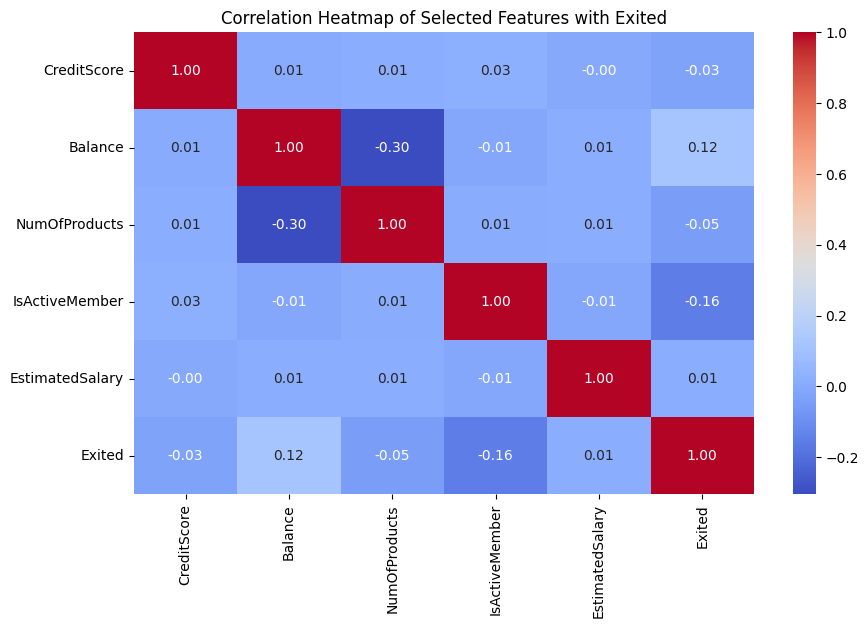

In [4]:
selected_features = ['CreditScore', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']
eda_data = data[selected_features + ['Exited']]

# Compute the correlation matrix
corr_matrix = eda_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Selected Features with Exited')
plt.show()


# Feature Selection using  chi-square Test

In [5]:

X = pd.get_dummies(X, drop_first=True)
selector = SelectKBest(chi2, k=5)
selector.fit(X, data['Exited'])
selected_features = X.columns[selector.get_support()]
print("Top 5 selected features using chi-square test:", selected_features)


Top 5 selected features using chi-square test: Index(['CreditScore', 'Balance', 'NumOfProducts', 'IsActiveMember',
       'EstimatedSalary'],
      dtype='object')


# FINDING DISTRIBUTION

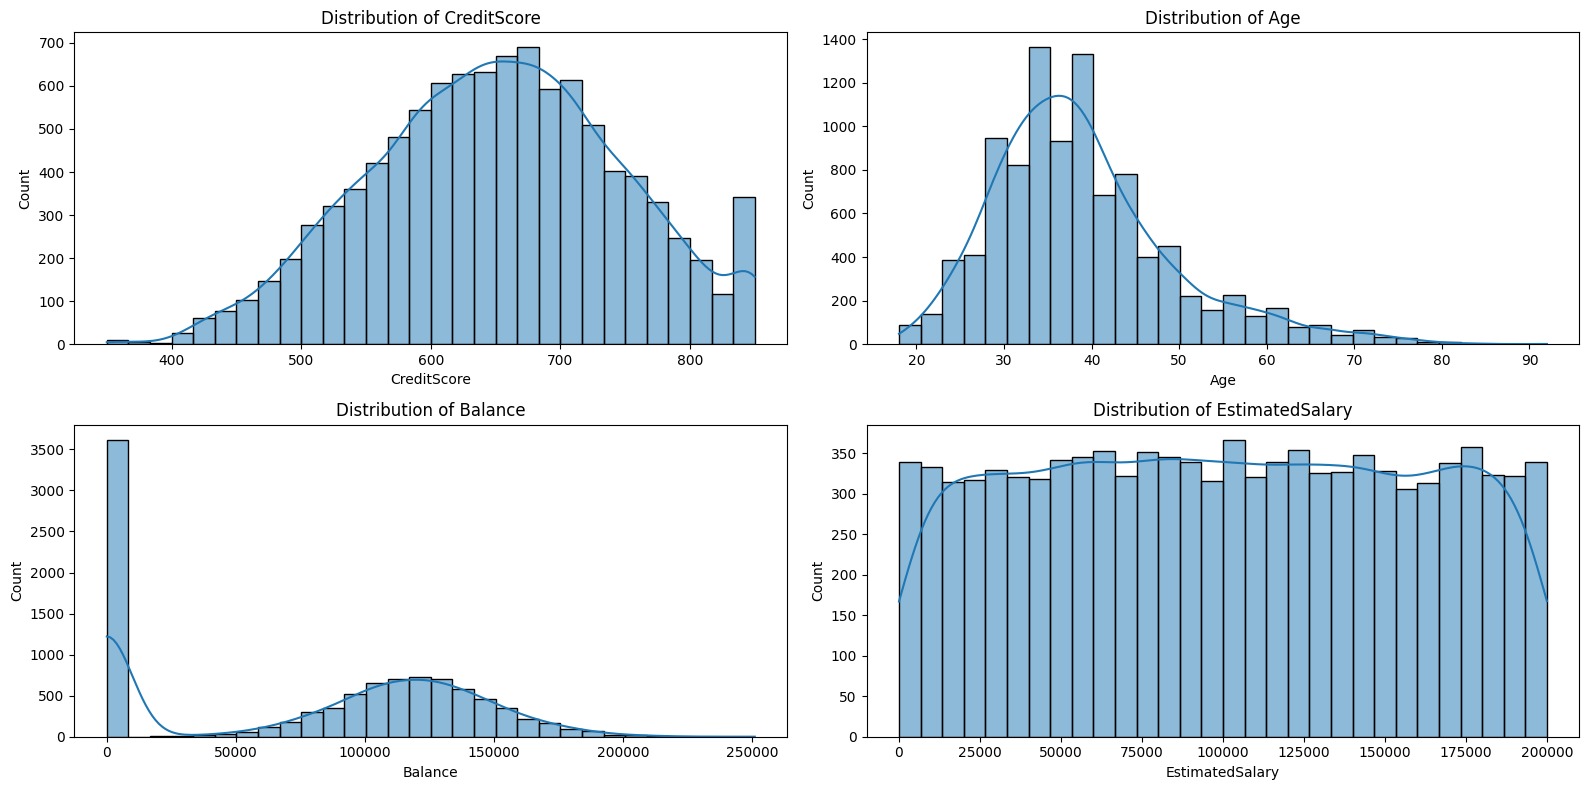

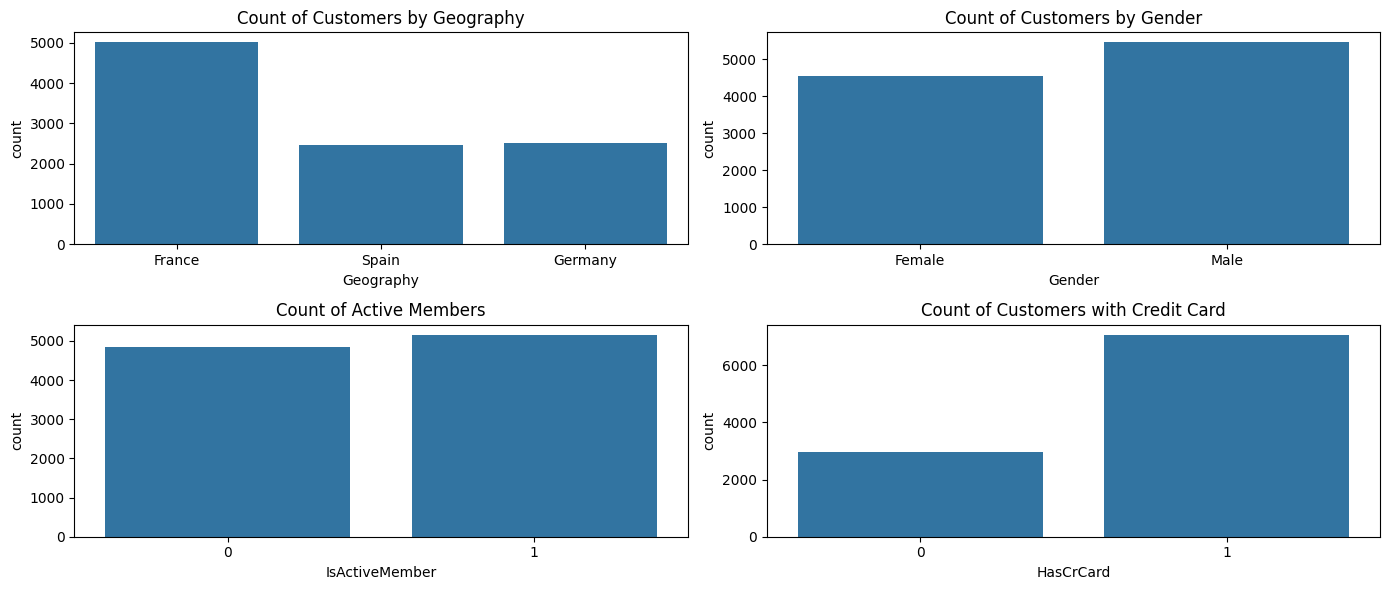

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

In [19]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(data['CreditScore'], bins=30, kde=True)
plt.title('Distribution of CreditScore')

plt.subplot(2, 2, 2)
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Distribution of Age')

plt.subplot(2, 2, 3)
sns.histplot(data['Balance'], bins=30, kde=True)
plt.title('Distribution of Balance')

plt.subplot(2, 2, 4)
sns.histplot(data['EstimatedSalary'], bins=30, kde=True)
plt.title('Distribution of EstimatedSalary')

plt.tight_layout()
plt.show()

# 2. Categorical Variables Analysis
plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
sns.countplot(x='Geography', data=data)
plt.title('Count of Customers by Geography')

plt.subplot(2, 2, 2)
sns.countplot(x='Gender', data=data)
plt.title('Count of Customers by Gender')

plt.subplot(2, 2, 3)
sns.countplot(x='IsActiveMember', data=data)
plt.title('Count of Active Members')

plt.subplot(2, 2, 4)
sns.countplot(x='HasCrCard', data=data)
plt.title('Count of Customers with Credit Card')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))



# SPLITTING TRAIN/TEST (80/20)

In [20]:

X = data.drop(columns=['CreditScore'])
y = data['CreditScore']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 8000
Testing set size: 2000
